# How Long Does Avalanche Debris Last in Sentinel-1 SAR?

Large debris polygons from the Sawtooth 2024-2025 season shown as
dB difference maps (post - baseline) at increasing time offsets.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from rasterio.features import rasterize
from rasterio.transform import from_origin
from shapely.geometry import mapping
from pathlib import Path

In [8]:
SEASON_NC = Path('../../local/issw/dual_tau_output/Sawtooth_&_Western_Smoky_Mtns/season_dataset.nc')
DEBRIS_GPKG = Path('../../local/issw/debris_shapes.gpkg')
ZONE = 'Sawtooth_&_Western_Smoky_Mtns'
EVENT_DATES = ['2025-02-04', '2025-01-25']
TRACK = 71  # ascending pass, 21 acquisitions

In [9]:
ds = xr.open_dataset(SEASON_NC)
if not np.issubdtype(ds['time'].dtype, np.datetime64):
    ds['time'] = pd.to_datetime(ds['time'].values)

# Reproject debris polygons to dataset CRS (lat/lon)
debris_gdf = gpd.read_file(DEBRIS_GPKG)
debris_gdf = debris_gdf.to_crs('EPSG:4326')

saw = debris_gdf[
    (debris_gdf['zone'] == ZONE) & debris_gdf['date'].isin(EVENT_DATES)
].copy()
saw['area_m2'] = saw.to_crs('EPSG:32611').geometry.area

# De-duplicate by centroid
saw['cx'] = saw.geometry.centroid.x.round(3)
saw['cy'] = saw.geometry.centroid.y.round(3)
unique = (
    saw.sort_values('area_m2', ascending=False)
    .drop_duplicates(subset=['cx', 'cy', 'date'])
    .head(6)
)

print(f'{len(unique)} debris polygons selected')
for _, r in unique.iterrows():
    print(f'  {r["date"]} track {r["track_idx"]:>5}  {r["area_m2"]/1e3:.0f} k m2')

6 debris polygons selected
  2025-02-04 track  2634  416 k m2
  2025-02-04 track  1176  396 k m2
  2025-01-25 track  2334  335 k m2
  2025-02-04 track  1658  238 k m2
  2025-01-25 track  2902  233 k m2
  2025-02-04 track  1321  227 k m2


/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/2574364197.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  saw['cx'] = saw.geometry.centroid.x.round(3)
/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/2574364197.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  saw['cy'] = saw.geometry.centroid.y.round(3)


In [10]:
# Build rasterize transform from dataset grid
y_vals = ds.y.values
x_vals = ds.x.values
dx = abs(float(x_vals[1] - x_vals[0]))
dy = abs(float(y_vals[1] - y_vals[0]))
# y is descending, so origin is top-left
TRANSFORM = from_origin(float(x_vals[0]) - dx/2, float(y_vals[0]) + dy/2, dx, dy)
NY, NX = len(y_vals), len(x_vals)

def get_debris_crop(geom, pad=25):
    """Rasterize polygon, return (mask, yslice, xslice) cropped with padding."""
    full_mask = rasterize(
        [(mapping(geom), 1)],
        out_shape=(NY, NX),
        transform=TRANSFORM,
        fill=0, dtype='uint8',
    ).astype(bool)
    rows, cols = np.where(full_mask)
    if len(rows) == 0:
        return None, None, None
    r0, r1 = max(0, rows.min() - pad), min(NY, rows.max() + pad + 1)
    c0, c1 = max(0, cols.min() - pad), min(NX, cols.max() + pad + 1)
    return full_mask[r0:r1, c0:c1], slice(r0, r1), slice(c0, c1)

# Track times
track_mask = ds['track'].values == TRACK
track_times = pd.DatetimeIndex(ds.time.values[track_mask])
print(f'Track {TRACK}: {len(track_times)} acquisitions, {str(track_times[0])[:10]} to {str(track_times[-1])[:10]}')

Track 71: 20 acquisitions, 2024-09-11 to 2025-04-27


/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4273361705.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


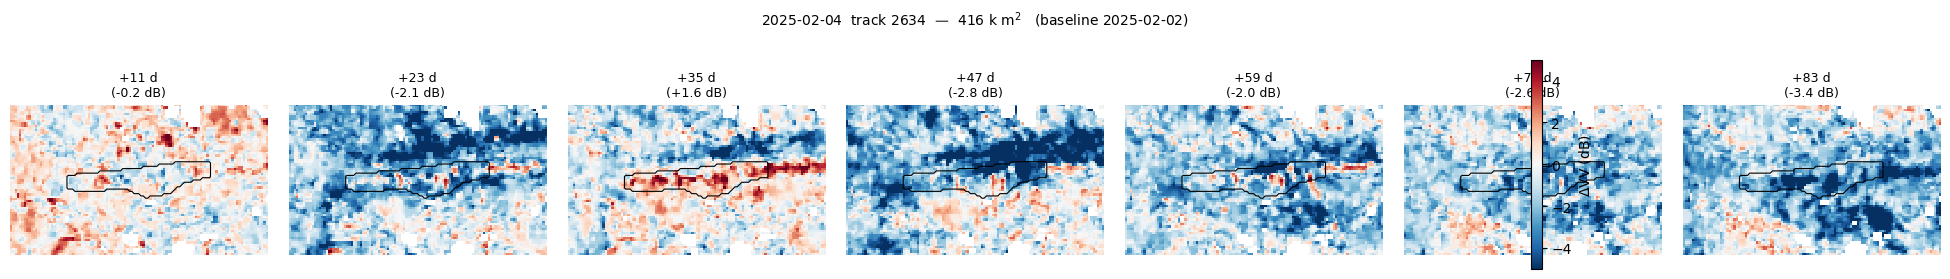

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4273361705.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


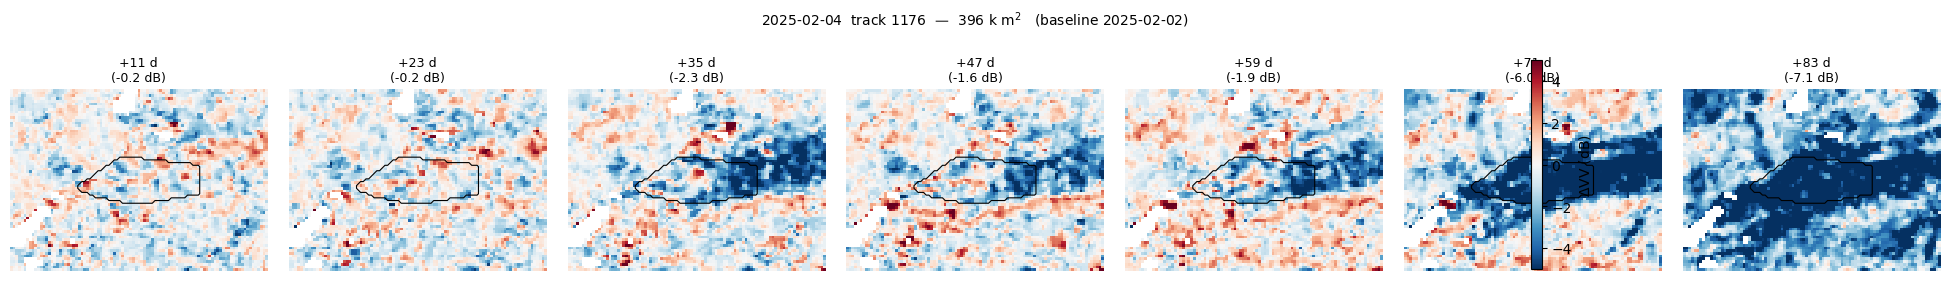

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4273361705.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


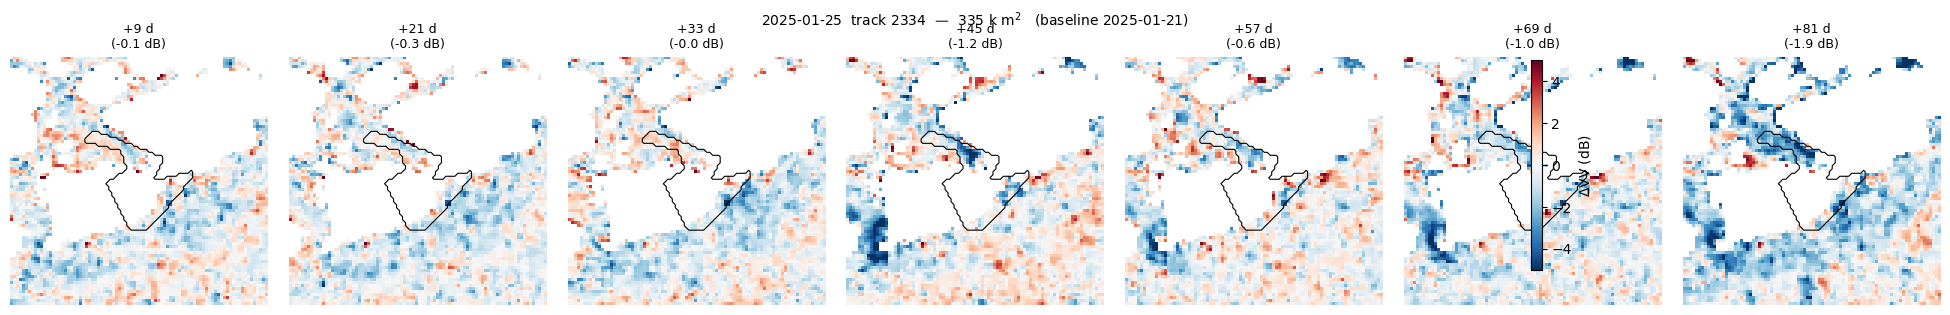

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4273361705.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


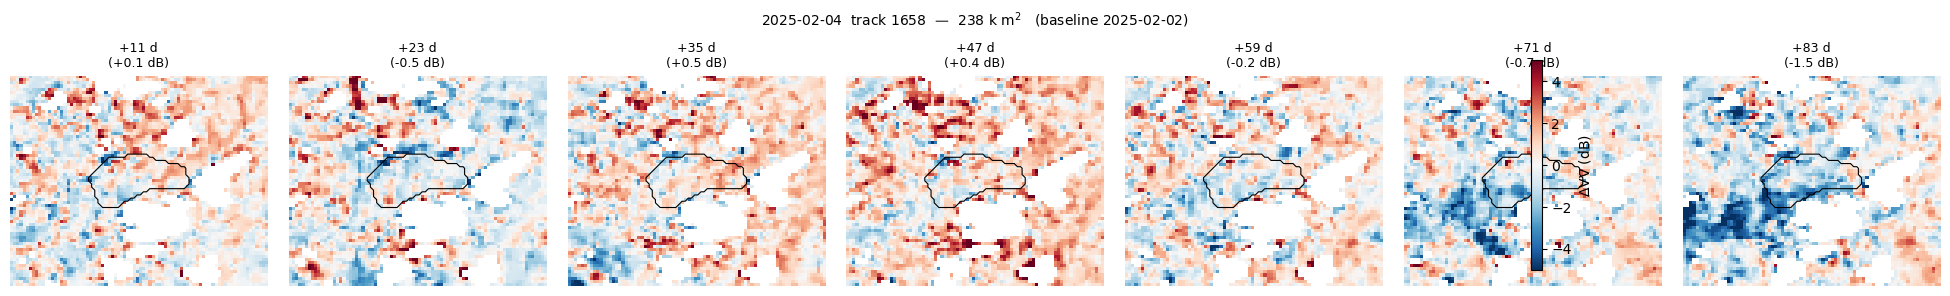

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4273361705.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


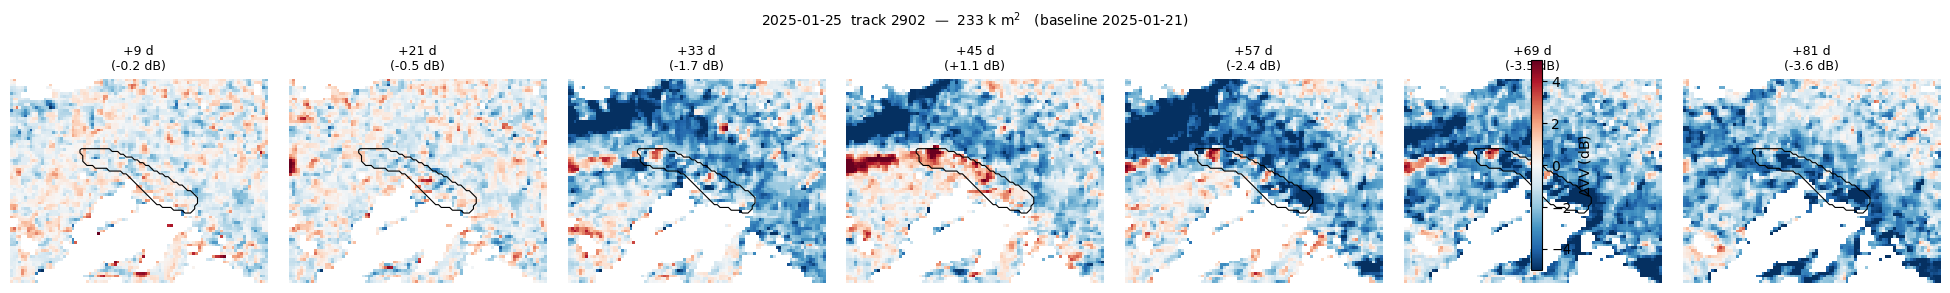

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4273361705.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


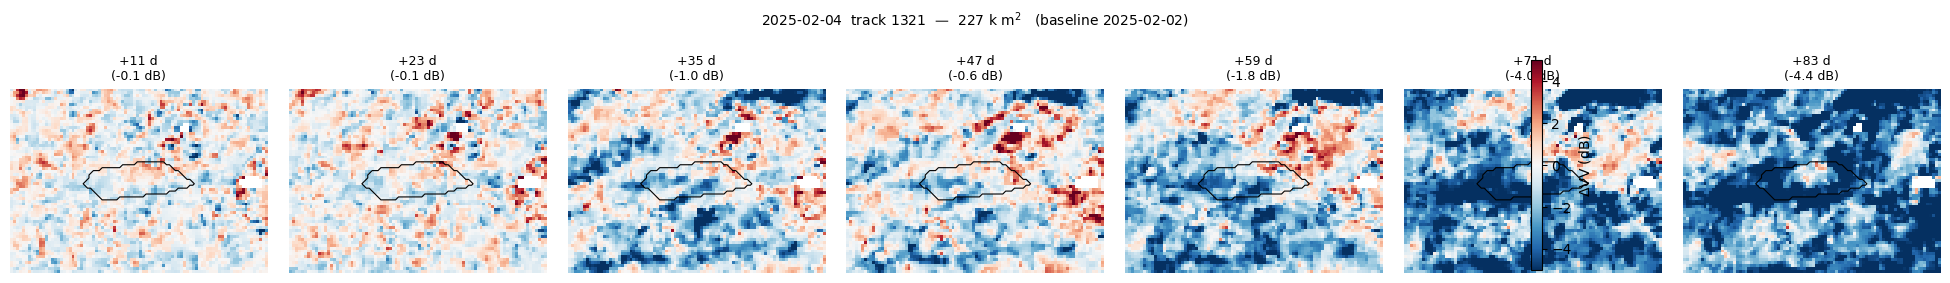

In [11]:
TARGET_OFFSETS = [0, 12, 24, 36, 48, 60, 72, 84]
NORM = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)

for _, debris_row in unique.iterrows():
    event_date = debris_row['date']
    event_dt = np.datetime64(event_date)
    
    mask, ysl, xsl = get_debris_crop(debris_row.geometry, pad=25)
    if mask is None:
        print(f'Skipping {debris_row["key"]} — outside grid')
        continue
    
    # Baseline: last track acquisition before event
    pre = track_times[track_times < event_dt]
    if len(pre) == 0:
        continue
    t_base = pre[-1]
    vv_base = ds['VV'].sel(time=t_base).values[ysl, xsl]
    
    # Post-event acquisitions
    post = track_times[track_times >= event_dt]
    
    # Select panels at target offsets
    panels = []
    for target_d in TARGET_OFFSETS:
        diffs = np.abs((post - event_dt) / np.timedelta64(1, 'D') - target_d)
        best_idx = diffs.argmin()
        if diffs[best_idx] > 8:
            continue
        t = post[best_idx]
        days = (t - event_dt) / np.timedelta64(1, 'D')
        diff = ds['VV'].sel(time=t).values[ysl, xsl] - vv_base
        panels.append((days, diff))
    
    if len(panels) < 3:
        continue
    
    # Plot
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.2))
    if n == 1:
        axes = [axes]
    
    for ax, (days, diff) in zip(axes, panels):
        im = ax.imshow(diff, cmap='RdBu_r', norm=NORM, interpolation='nearest')
        ax.contour(mask.astype(float), levels=[0.5], colors='k', linewidths=0.8)
        mean_in = np.nanmean(diff[mask])
        ax.set_title(f'+{days:.0f} d\n({mean_in:+.1f} dB)', fontsize=9)
        ax.axis('off')
    
    fig.colorbar(im, ax=axes, label='$\\Delta$VV (dB)', shrink=0.85, pad=0.02)
    fig.suptitle(
        f'{event_date}  track {debris_row["track_idx"]}  —  '
        f'{debris_row["area_m2"]/1e3:.0f} k m$^2$   '
        f'(baseline {str(t_base)[:10]})',
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()

## Same panels for VH

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4272750296.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


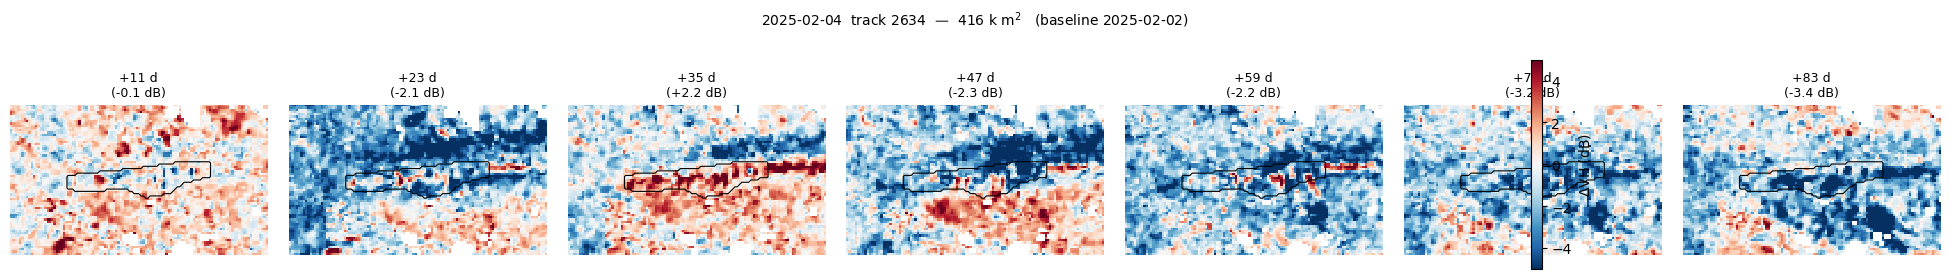

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4272750296.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


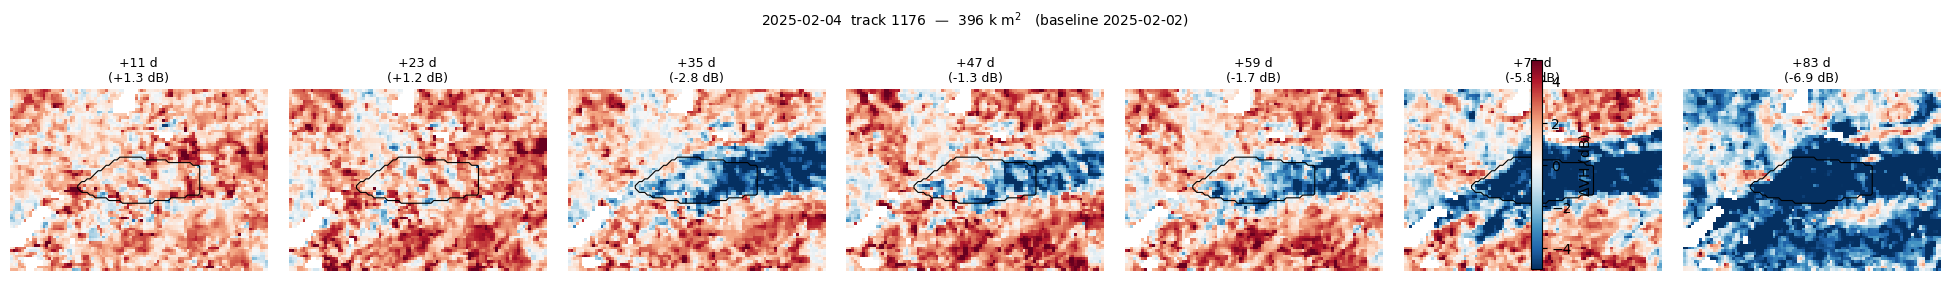

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4272750296.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


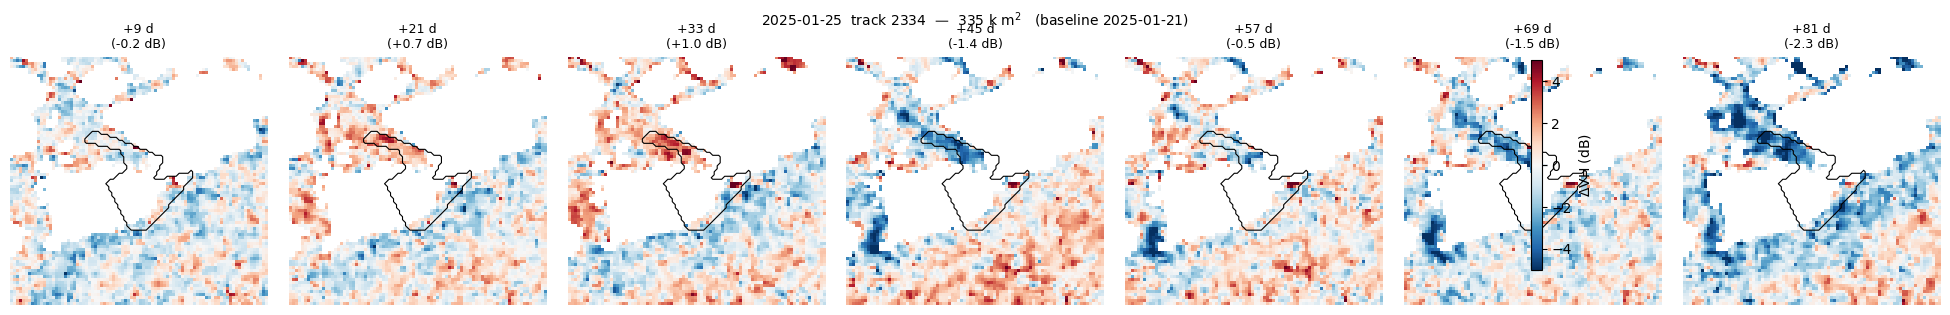

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4272750296.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


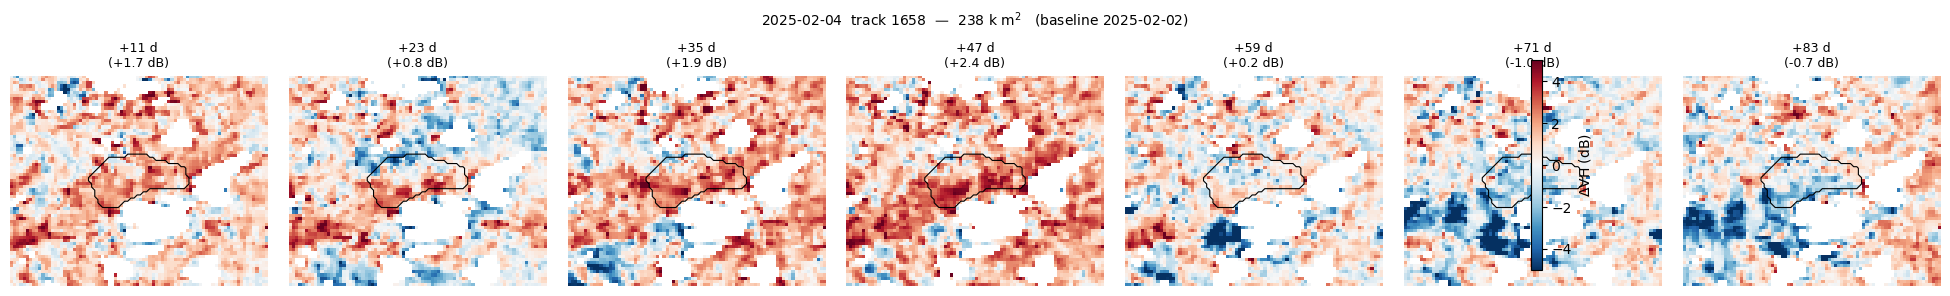

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4272750296.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


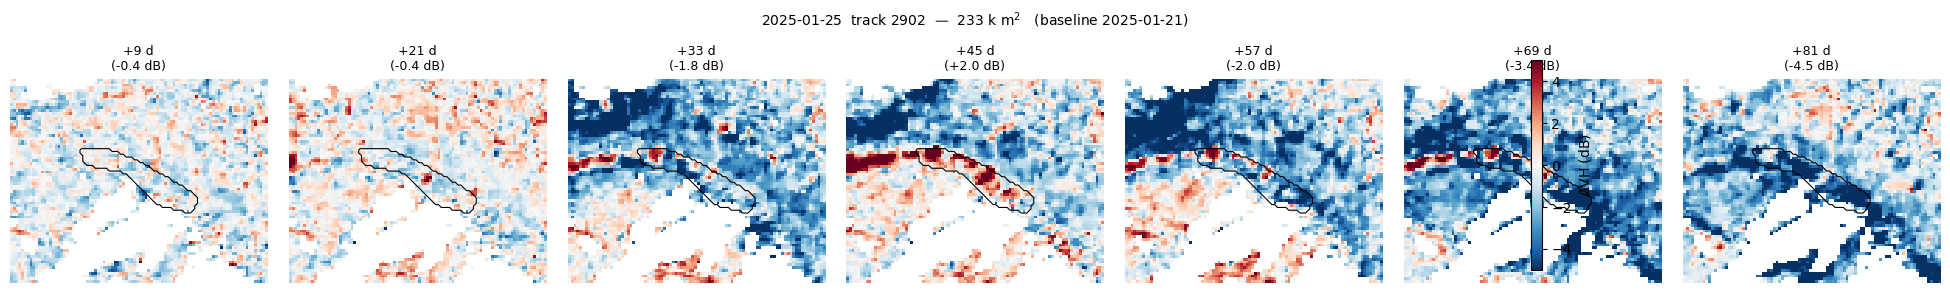

/var/folders/4w/2g069ftd76n47s6rqm4n3kmw0000gq/T/ipykernel_62002/4272750296.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


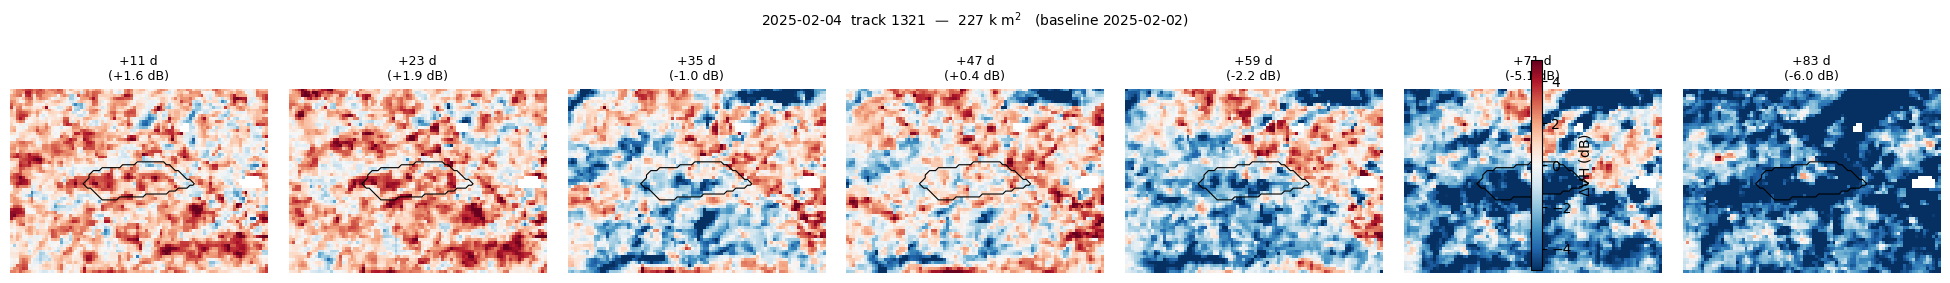

In [12]:
for _, debris_row in unique.iterrows():
    event_date = debris_row['date']
    event_dt = np.datetime64(event_date)
    
    mask, ysl, xsl = get_debris_crop(debris_row.geometry, pad=25)
    if mask is None:
        continue
    
    pre = track_times[track_times < event_dt]
    if len(pre) == 0:
        continue
    t_base = pre[-1]
    vh_base = ds['VH'].sel(time=t_base).values[ysl, xsl]
    post = track_times[track_times >= event_dt]
    
    panels = []
    for target_d in TARGET_OFFSETS:
        diffs = np.abs((post - event_dt) / np.timedelta64(1, 'D') - target_d)
        best_idx = diffs.argmin()
        if diffs[best_idx] > 8:
            continue
        t = post[best_idx]
        days = (t - event_dt) / np.timedelta64(1, 'D')
        diff = ds['VH'].sel(time=t).values[ysl, xsl] - vh_base
        panels.append((days, diff))
    
    if len(panels) < 3:
        continue
    
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.2))
    if n == 1:
        axes = [axes]
    
    for ax, (days, diff) in zip(axes, panels):
        im = ax.imshow(diff, cmap='RdBu_r', norm=NORM, interpolation='nearest')
        ax.contour(mask.astype(float), levels=[0.5], colors='k', linewidths=0.8)
        mean_in = np.nanmean(diff[mask])
        ax.set_title(f'+{days:.0f} d\n({mean_in:+.1f} dB)', fontsize=9)
        ax.axis('off')
    
    fig.colorbar(im, ax=axes, label='$\\Delta$VH (dB)', shrink=0.85, pad=0.02)
    fig.suptitle(
        f'{event_date}  track {debris_row["track_idx"]}  —  '
        f'{debris_row["area_m2"]/1e3:.0f} k m$^2$   '
        f'(baseline {str(t_base)[:10]})',
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()

In [7]:
ds.close()